# CSE Market Data Analysis
Connecting to PostgreSQL and visualising extracted stock market data.

In [2]:
pip install psycopg2 pandas matplotlib seaborn


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for psycopg2: filename=psycopg2-2.9.12-cp312-cp312-linux_x86_64.whl size=549479 sha256=4b8445cfc00aeb204dd6353116e418faebfad81c292cee21c6607ab632ca87ea
  Stored in directory: /home/codespace/.cache/pip/wheels/04/74/ff/720d90509a7e28eeecdaf470a74ba12afb31f8857624440482
Successfully built psycopg2
Note: you may need to restart the kernel to use updated packages.


In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

DB = dict(host='localhost', port=5432, dbname='airflow', user='airflow', password='airflow')

def query(sql):
    conn = psycopg2.connect(**DB)
    df = pd.read_sql_query(sql, conn)
    conn.close()
    return df

print('Connected to PostgreSQL successfully!')

Connected to PostgreSQL successfully!


## 1. Stock Price Comparison

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


     symbol                    company_name  last_traded_price  change_pct  \
0      EXPO     Expolanka Holdings (Global)              66.27      -1.909   
1       HDB    HDFC Bank (Regional Banking)              25.51      -2.261   
2      STER         Sterling Infrastructure              16.74       0.000   
3   USD/LKR   US Dollar to Sri Lankan Rupee             317.26         NaN   
4      EXPO     Expolanka Holdings (Global)              66.27      -1.909   
5       HDB    HDFC Bank (Regional Banking)              25.51      -2.261   
6      STER         Sterling Infrastructure              16.74       0.000   
7      GOOG    Alphabet Inc (Tech - Global)             337.75       0.006   
8      MSFT  Microsoft Corp (Tech - Global)             415.75      -3.966   
9      ORIT     Oritani Financial (Finance)              18.60       0.000   
10  USD/LKR   US Dollar to Sri Lankan Rupee             317.26         NaN   
11     EXPO     Expolanka Holdings (Global)              66.27  

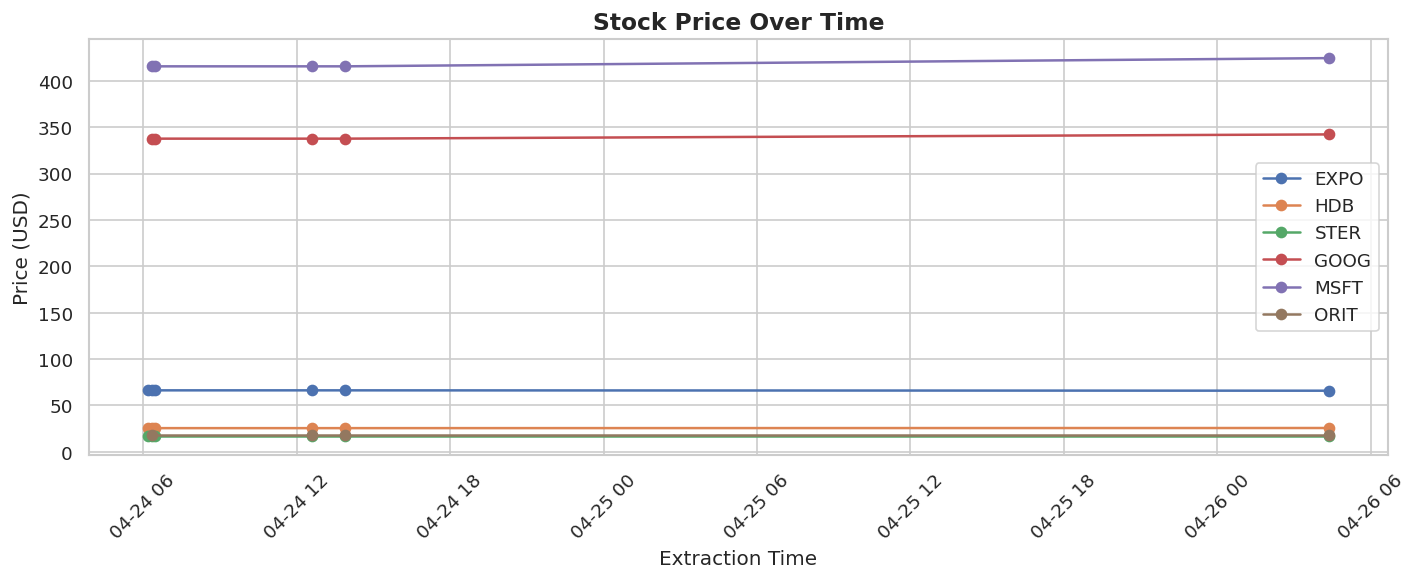

In [2]:
df = query("SELECT symbol, company_name, last_traded_price, change_pct, trade_date, extracted_at FROM cse_stock_prices ORDER BY extracted_at")
print(df)

fig, ax = plt.subplots(figsize=(12,5))
stocks_only = df[df['symbol'] != 'USD/LKR']
for symbol in stocks_only['symbol'].unique():
    subset = stocks_only[stocks_only['symbol'] == symbol]
    ax.plot(subset['extracted_at'], subset['last_traded_price'], marker='o', label=symbol)
ax.set_title('Stock Price Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Extraction Time')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_stock_prices.png', bbox_inches='tight')
plt.show()

## 2. USD/LKR Exchange Rate Trend

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


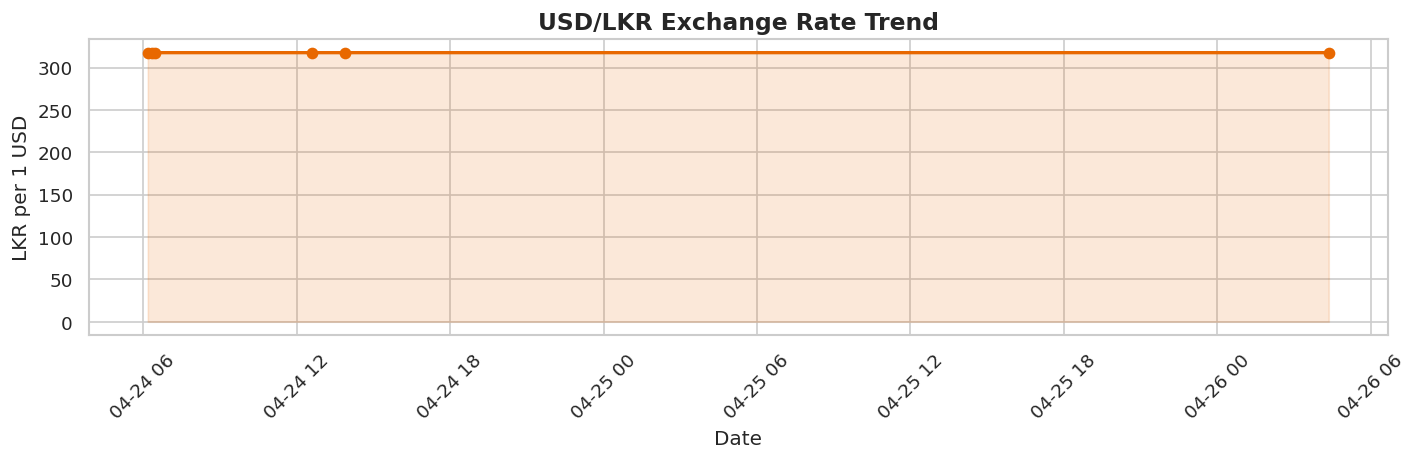

In [3]:
df_lkr = query("SELECT last_traded_price, extracted_at FROM cse_stock_prices WHERE symbol = 'USD/LKR' ORDER BY extracted_at")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(df_lkr['extracted_at'], df_lkr['last_traded_price'], color='#e86800', linewidth=2, marker='o')
ax.fill_between(df_lkr['extracted_at'], df_lkr['last_traded_price'], alpha=0.15, color='#e86800')
ax.set_title('USD/LKR Exchange Rate Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('LKR per 1 USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_usd_lkr.png', bbox_inches='tight')
plt.show()

## 3. Daily Price Change % Comparison

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


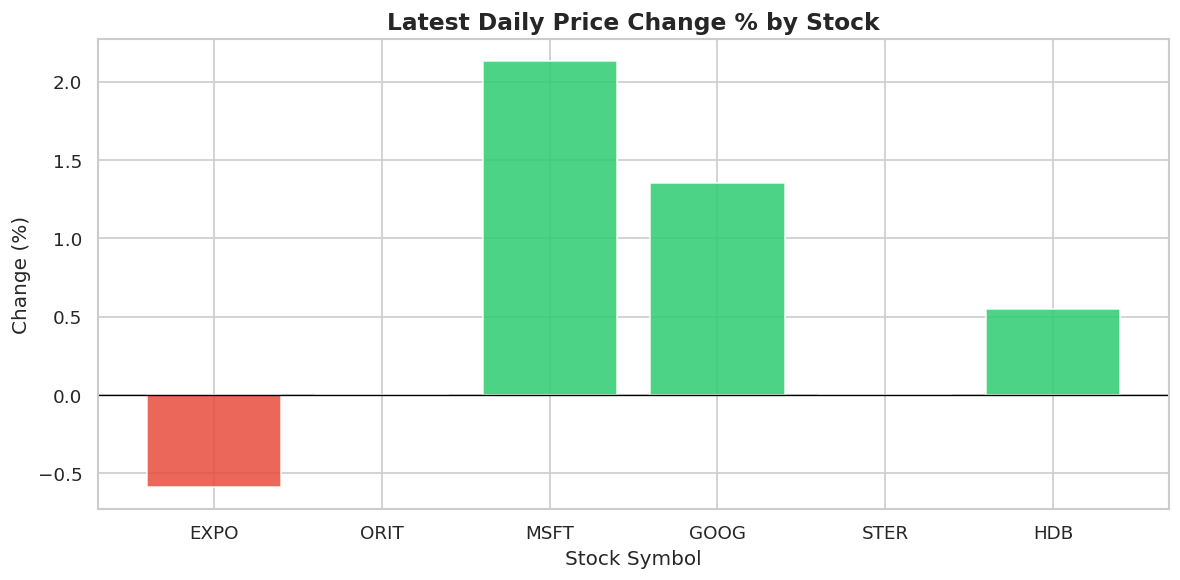

In [4]:
df_change = query("SELECT symbol, change_pct, trade_date FROM cse_stock_prices WHERE symbol != 'USD/LKR' AND change_pct IS NOT NULL ORDER BY extracted_at DESC LIMIT 20")
latest = df_change.drop_duplicates(subset='symbol', keep='first')

colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in latest['change_pct']]
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(latest['symbol'], latest['change_pct'], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Latest Daily Price Change % by Stock', fontsize=14, fontweight='bold')
ax.set_xlabel('Stock Symbol')
ax.set_ylabel('Change (%)')
plt.tight_layout()
plt.savefig('chart_change_pct.png', bbox_inches='tight')
plt.show()

## 4. Advances vs Declines Over Time

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


   trade_date  advances  declines  unchanged  aspi_change_pct  total_turnover
0  2026-04-24         0         2          1           -1.390       278869592
1  2026-04-24         1         3          2           -1.355     20745549482
2  2026-04-24         1         3          1           -1.626     20745484642
3  2026-04-24         1         3          2           -1.355     20745549482
4  2026-04-24         1         3          2           -1.355     20745549482
5  2026-04-26         3         1          2            0.574     18076617959


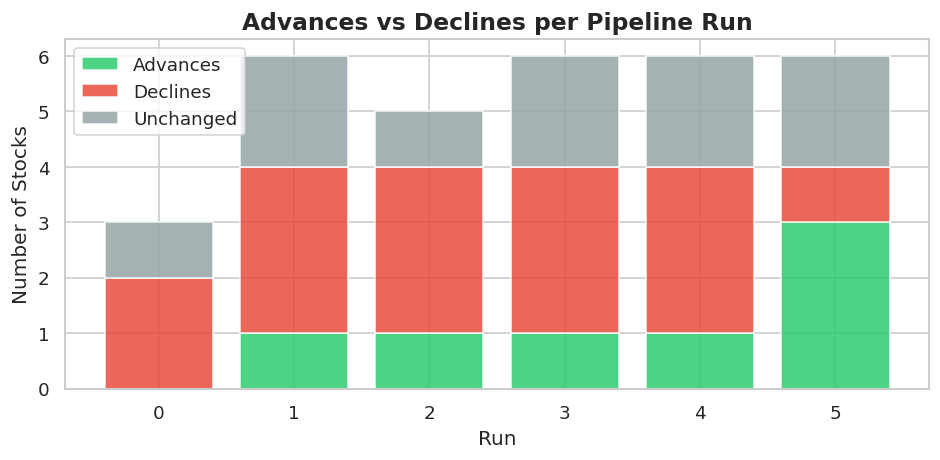

In [7]:
df_summary = query("SELECT trade_date, advances, declines, unchanged, aspi_change_pct, total_turnover FROM cse_daily_summary ORDER BY extracted_at")
print(df_summary)

fig, ax = plt.subplots(figsize=(8,4))
x = range(len(df_summary))
ax.bar(x, df_summary['advances'], label='Advances', color='#2ecc71', alpha=0.85)
ax.bar(x, df_summary['declines'], bottom=df_summary['advances'], label='Declines', color='#e74c3c', alpha=0.85)
ax.bar(x, df_summary['unchanged'], bottom=df_summary['advances']+df_summary['declines'], label='Unchanged', color='#95a5a6', alpha=0.85)
ax.set_title('Advances vs Declines per Pipeline Run', fontsize=14, fontweight='bold')
ax.set_xlabel('Run')
ax.set_ylabel('Number of Stocks')
ax.legend()
plt.tight_layout()
plt.savefig('chart_advances_declines.png', bbox_inches='tight')
plt.show()

## 5. Top Gainers and Losers

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


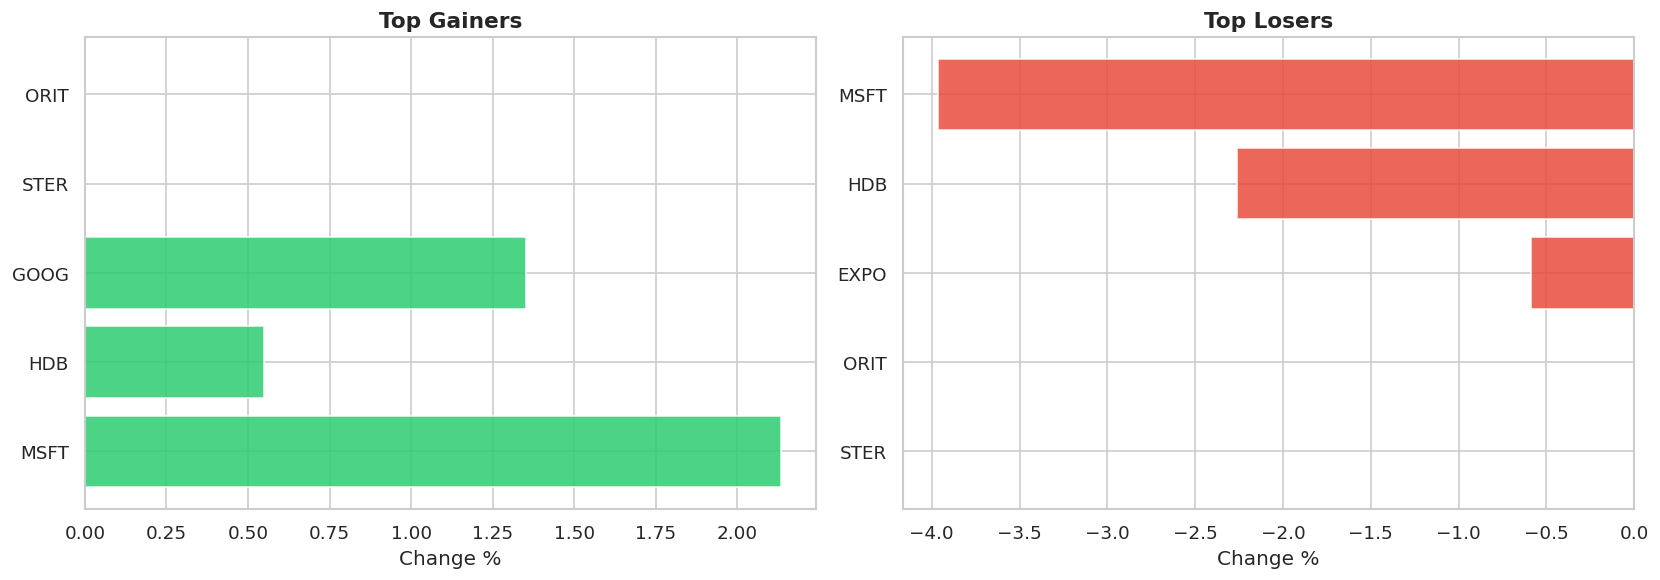

In [8]:
df_movers = query("SELECT symbol, company_name, change_pct, category FROM cse_top_gainers_losers ORDER BY extracted_at DESC LIMIT 20")
df_movers = df_movers.drop_duplicates(subset=['symbol','category'], keep='first')

fig, axes = plt.subplots(1, 2, figsize=(14,5))

gainers = df_movers[df_movers['category']=='gainer'].head(5)
axes[0].barh(gainers['symbol'], gainers['change_pct'], color='#2ecc71', alpha=0.85)
axes[0].set_title('Top Gainers', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Change %')

losers = df_movers[df_movers['category']=='loser'].head(5)
axes[1].barh(losers['symbol'], losers['change_pct'], color='#e74c3c', alpha=0.85)
axes[1].set_title('Top Losers', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Change %')

plt.tight_layout()
plt.savefig('chart_movers.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


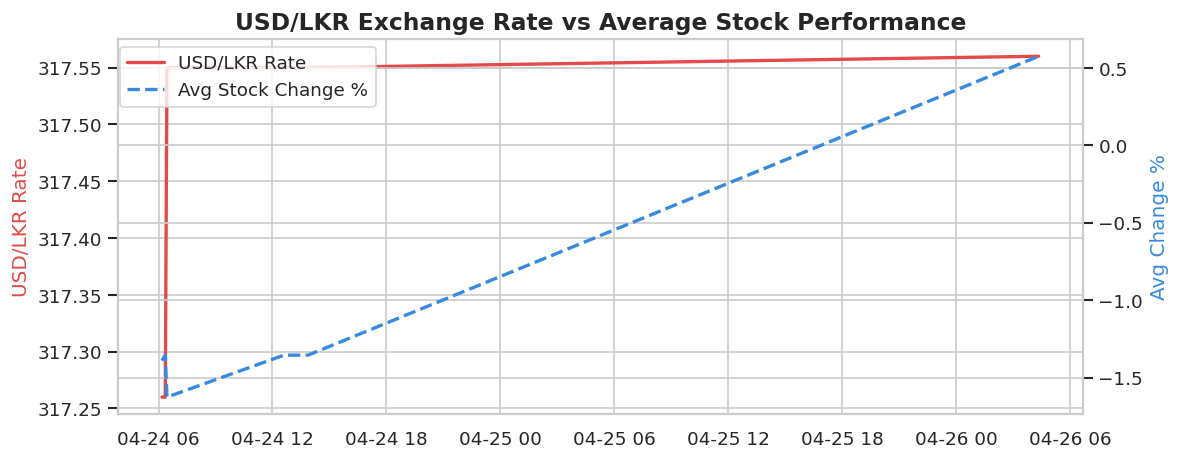

In [17]:
df_lkr = query("SELECT last_traded_price, extracted_at FROM cse_stock_prices WHERE symbol='USD/LKR' ORDER BY extracted_at")
df_avg = query("SELECT AVG(change_pct) as avg_change, extracted_at FROM cse_stock_prices WHERE symbol != 'USD/LKR' GROUP BY extracted_at ORDER BY extracted_at")

fig, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(df_lkr['extracted_at'], df_lkr['last_traded_price'], color='#E24B4A', linewidth=2, label='USD/LKR Rate')
ax1.set_ylabel('USD/LKR Rate', color='#E24B4A')
ax2 = ax1.twinx()
ax2.plot(df_avg['extracted_at'], df_avg['avg_change'], color='#378ADD', linewidth=2, linestyle='--', label='Avg Stock Change %')
ax2.set_ylabel('Avg Change %', color='#378ADD')
ax1.set_title('USD/LKR Exchange Rate vs Average Stock Performance', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_lkr_vs_stocks.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)
Task was destroyed but it is pending!
task: <Task pending name='Task-244' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/codespace/.local/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-245' coro=<Kernel.shell_main() running at /home/codespace/.local/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/codespace/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/usr/local/python/3.12.1/lib/python3.12/site-packages/matplotlib/_api/__init__.py:86: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for k, v in kwargs.items():
Task was

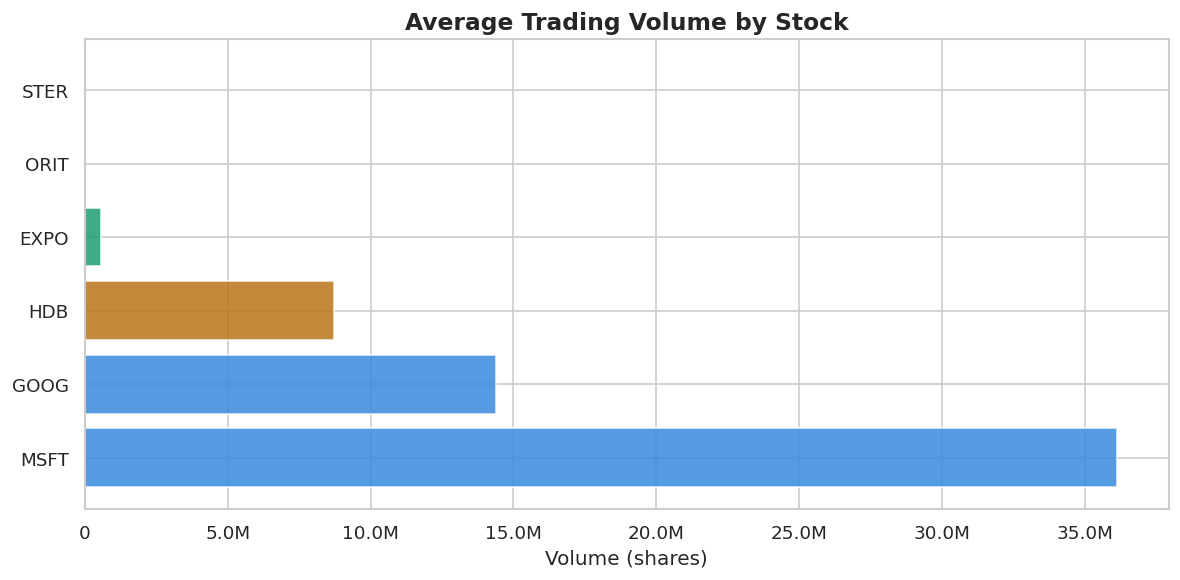

In [11]:
df_vol = query("SELECT symbol, AVG(volume) as avg_volume FROM cse_stock_prices WHERE symbol != 'USD/LKR' AND volume IS NOT NULL GROUP BY symbol ORDER BY avg_volume DESC")

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#378ADD' if s in ['GOOG','MSFT'] else '#1D9E75' if s == 'EXPO' else '#BA7517' for s in df_vol['symbol']]
ax.barh(df_vol['symbol'], df_vol['avg_volume'], color=colors, alpha=0.85)
ax.set_title('Average Trading Volume by Stock', fontsize=14, fontweight='bold')
ax.set_xlabel('Volume (shares)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('chart_volume.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


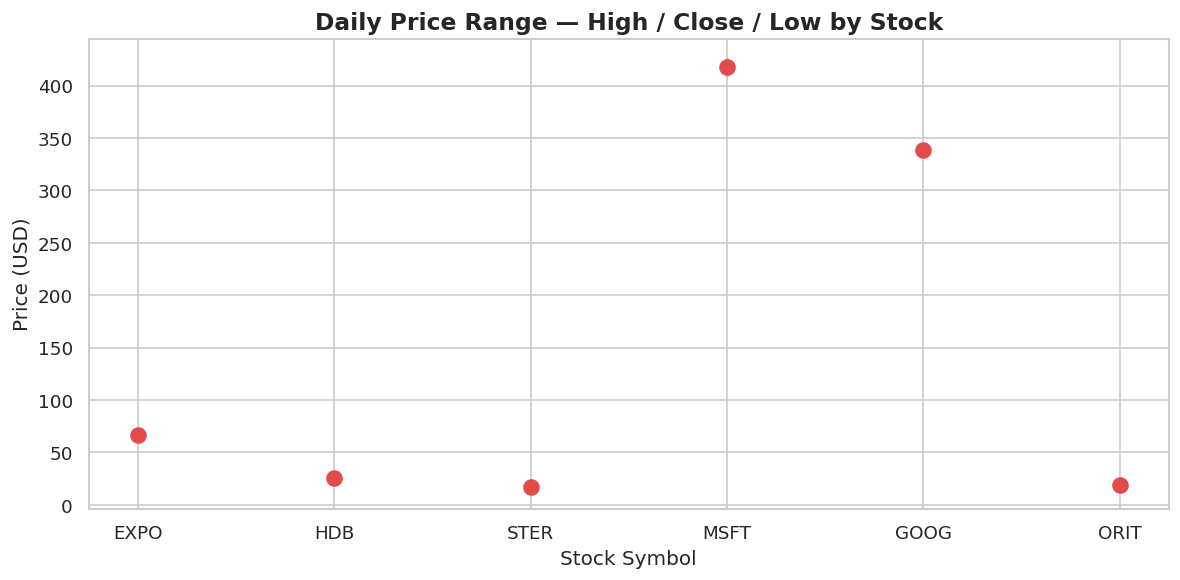

In [12]:
df_range = query("SELECT symbol, AVG(high_price) as high, AVG(low_price) as low, AVG(last_traded_price) as close FROM cse_stock_prices WHERE symbol != 'USD/LKR' GROUP BY symbol")

fig, ax = plt.subplots(figsize=(10,5))
for _, row in df_range.iterrows():
    ax.plot([row['symbol'], row['symbol']], [row['low'], row['high']], color='#378ADD', linewidth=4, alpha=0.4)
    ax.scatter(row['symbol'], row['close'], color='#E24B4A', zorder=5, s=80, label='Close' if _ == 0 else '')
ax.set_title('Daily Price Range — High / Close / Low by Stock', fontsize=14, fontweight='bold')
ax.set_xlabel('Stock Symbol')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('chart_price_range.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


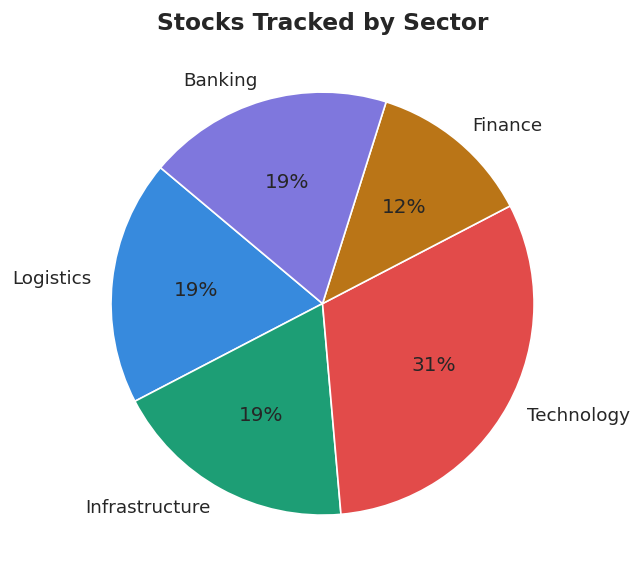

In [13]:
df_sector = query("SELECT sector, COUNT(*) as count FROM cse_stock_prices WHERE symbol != 'USD/LKR' GROUP BY sector")

fig, ax = plt.subplots(figsize=(8,5))
colors = ['#378ADD','#1D9E75','#E24B4A','#BA7517','#7F77DD']
ax.pie(df_sector['count'], labels=df_sector['sector'], autopct='%1.0f%%', colors=colors, startangle=140)
ax.set_title('Stocks Tracked by Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_sector_pie.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


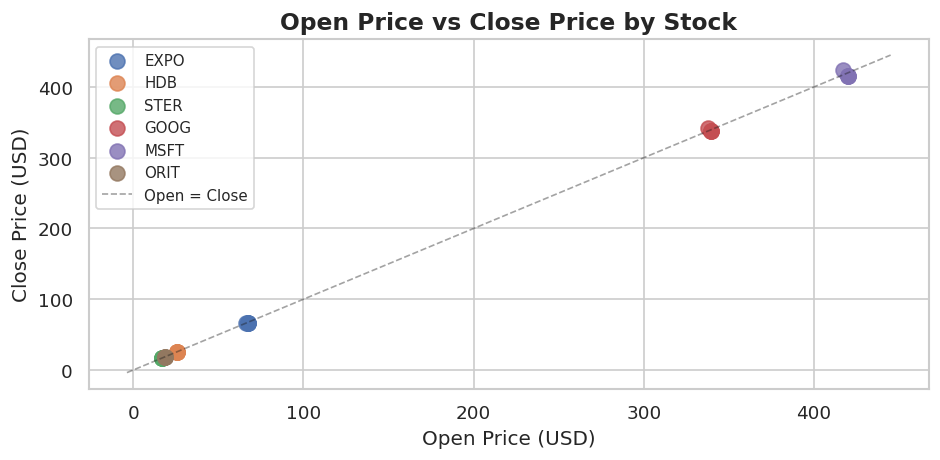

In [18]:
df_oc = query("SELECT symbol, open_price, last_traded_price as close_price FROM cse_stock_prices WHERE symbol != 'USD/LKR' AND open_price IS NOT NULL")

fig, ax = plt.subplots(figsize=(8,4))
for symbol in df_oc['symbol'].unique():
    sub = df_oc[df_oc['symbol']==symbol]
    ax.scatter(sub['open_price'], sub['close_price'], label=symbol, s=80, alpha=0.8)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.4, label='Open = Close')
ax.set_title('Open Price vs Close Price by Stock', fontsize=14, fontweight='bold')
ax.set_xlabel('Open Price (USD)')
ax.set_ylabel('Close Price (USD)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart_open_vs_close.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_21065/2821261220.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


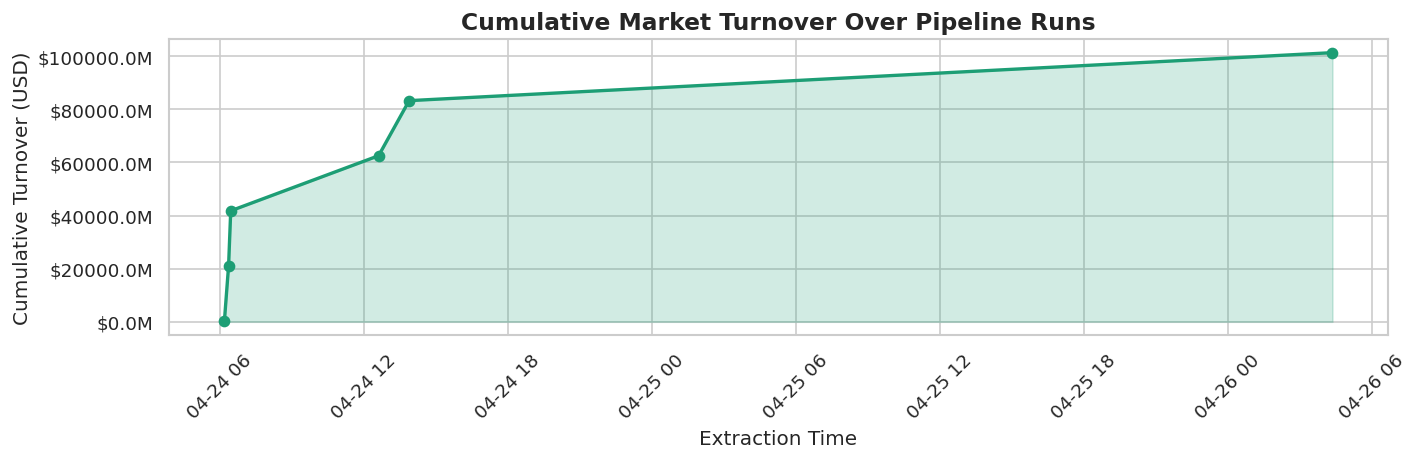

In [15]:
df_turn = query("SELECT extracted_at, SUM(turnover) as total_turnover FROM cse_stock_prices WHERE symbol != 'USD/LKR' GROUP BY extracted_at ORDER BY extracted_at")
df_turn['cumulative'] = df_turn['total_turnover'].cumsum()

fig, ax = plt.subplots(figsize=(12,4))
ax.fill_between(df_turn['extracted_at'], df_turn['cumulative'], alpha=0.2, color='#1D9E75')
ax.plot(df_turn['extracted_at'], df_turn['cumulative'], color='#1D9E75', linewidth=2, marker='o')
ax.set_title('Cumulative Market Turnover Over Pipeline Runs', fontsize=14, fontweight='bold')
ax.set_xlabel('Extraction Time')
ax.set_ylabel('Cumulative Turnover (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_cumulative_turnover.png', bbox_inches='tight')
plt.show()